# check  cdr RMSD 

### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

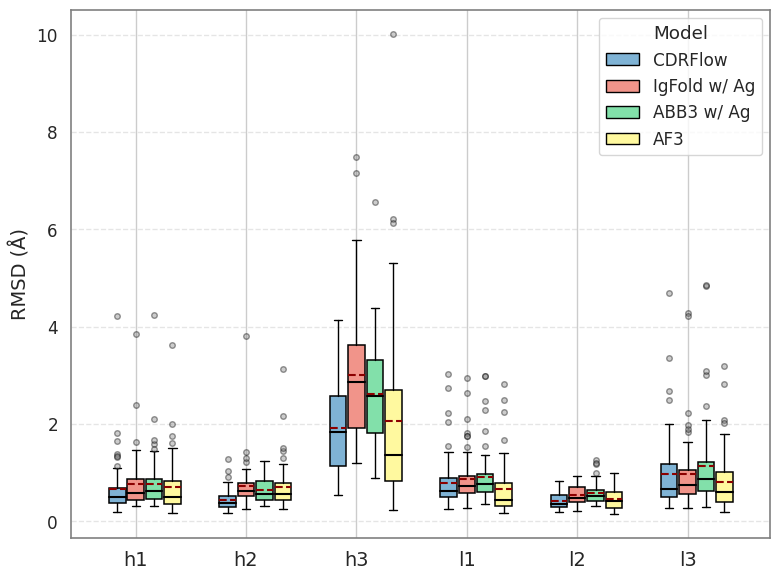

In [31]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import seaborn as sns
from Bio.PDB import PDBParser

def calculate_b_factor_mean(pdb_dir, start_residue=95, end_residue=102):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in os.listdir(pdb_dir):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())
                
        b_factors_avg.append(np.mean(b_factors))
        max_index = int(np.argmax(b_factors_avg))
    return max_index


pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
igfold_dir = '/home/psh/igfold_esm/test_code/eval_model/benchmark_after210930/real_original/only_cdr'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/af3_output_processed'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

rmsd_by_pdb = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_igfold = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_prev = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
h3_rmsd_by_pdb_af3 = {'h1':[], 'h2':[], 'h3':[], 'l1':[], 'l2':[], 'l3':[]}
keys = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']
pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        for key in keys:
            h3_rmsd_by_pdb_prev[key].append(prev_data[f'{key}_rms'])
    else:
        continue
    
    # Igfold에서 RMSD 가져오기 
    igfold_filepath = os.path.join(igfold_dir, pdb_id + '.json')
    if os.path.exists(igfold_filepath):
        with open(igfold_filepath, 'r') as f:
            igfold_data = json.load(f)
        for key in keys:
            h3_rmsd_by_pdb_igfold[key].append(igfold_data[f'{key}_rms'])
    else:
        continue

    # af3에서 RMSD 값 불러오기 
    sub_dir = os.path.join(af3_dir, pdb_id)
    max_index = calculate_b_factor_mean(sub_dir)
    
    sample_rmsds = []  # 각 샘플의 전체 CDR RMSD 정보를 저장

    samples_list = os.listdir(sub_dir)
    sample = samples_list[max_index]
    cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
    with open(cdr_info, 'r') as f:
        data = json.load(f)

    # 각 CDR에 대해 저장
    for key in keys:
        h3_rmsd_by_pdb_af3[key].append(data[f'{key}_rms'])

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)

    sample_rmsds = []  # 각 샘플의 전체 CDR RMSD 정보를 저장

    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)

        # 전체 CDR 정보를 함께 저장
        sample_rmsds.append({
            'h1': data['h1_rms'],
            'h2': data['h2_rms'],
            'h3': data['h3_rms'],
            'l1': data['l1_rms'],
            'l2': data['l2_rms'],
            'l3': data['l3_rms'],
        })

    # h3 기준으로 정렬하고 10번째로 작은 샘플 선택
    if len(sample_rmsds) >= 10:
        sorted_samples = sorted(sample_rmsds, key=lambda x: x['h3'])
        best_sample = sorted_samples[19]  # 10번째로 작은 h3 RMSD의 샘플
    else:
        # 샘플 수가 부족한 경우, 가장 작은 h3 RMSD 사용
        sorted_samples = sorted(sample_rmsds, key=lambda x: x['h3'])
        best_sample = sorted_samples[0]

    # 각 CDR에 대해 저장
    for key in keys:
        rmsd_by_pdb[key].append(best_sample[key])

# 스타일 세팅
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['axes.edgecolor'] = 'gray'
plt.rcParams['axes.linewidth'] = 1.2

model_names = ['CDRFlow', 'IgFold w/ Ag','ABB3 w/ Ag', 'AF3']
colors = ['#7FB3D5', '#F1948A', '#82E0AA', "#FFF99F"]  # 좀 더 세련된 컬러
cdrs = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']

data_to_plot = []
positions = []
labels = []
legend_handles = []

width = 0.6
gap = 1.2  # 각 CDR 간 간격
group_width = 0.2  # 그룹 내 간격

for i, cdr in enumerate(cdrs):
    values = [
        rmsd_by_pdb[cdr],    
        h3_rmsd_by_pdb_igfold[cdr],         # CDRFlow
        h3_rmsd_by_pdb_prev[cdr],    # Prev
        h3_rmsd_by_pdb_af3[cdr],     # AF3
    ]
    for j, val in enumerate(values):
        pos = i * gap + j * group_width
        positions.append(pos)
        data_to_plot.append(val)
        labels.append(model_names[j])
        
# Boxplot 그리기
plt.figure(figsize=(8, 6))
box = plt.boxplot(
    data_to_plot,
    positions=positions,
    widths=group_width * 0.9,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    flierprops=dict(marker='o', markersize=4, linestyle='none', alpha=0.4, markerfacecolor='gray')
)

# 색상 적용
for patch, i in zip(box['boxes'], range(len(data_to_plot))):
    color = colors[i % 4]
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.1)

# 평균선, 중앙값 등 스타일 조정
for median in box['medians']:
    median.set(color='black', linewidth=1.5)

for mean in box['means']:
    mean.set(color='darkred', linewidth=1.5)

# X축 위치 및 레이블 지정
group_centers = [i * gap + group_width for i in range(len(cdrs))]
plt.xticks(group_centers, cdrs, fontsize=14)

# Legend 추가
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', label=model_names[i]) for i in range(4)]
plt.legend(handles=legend_handles, title='Model', loc='upper right')
plt.ylabel('RMSD (Å)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### violin plot version 

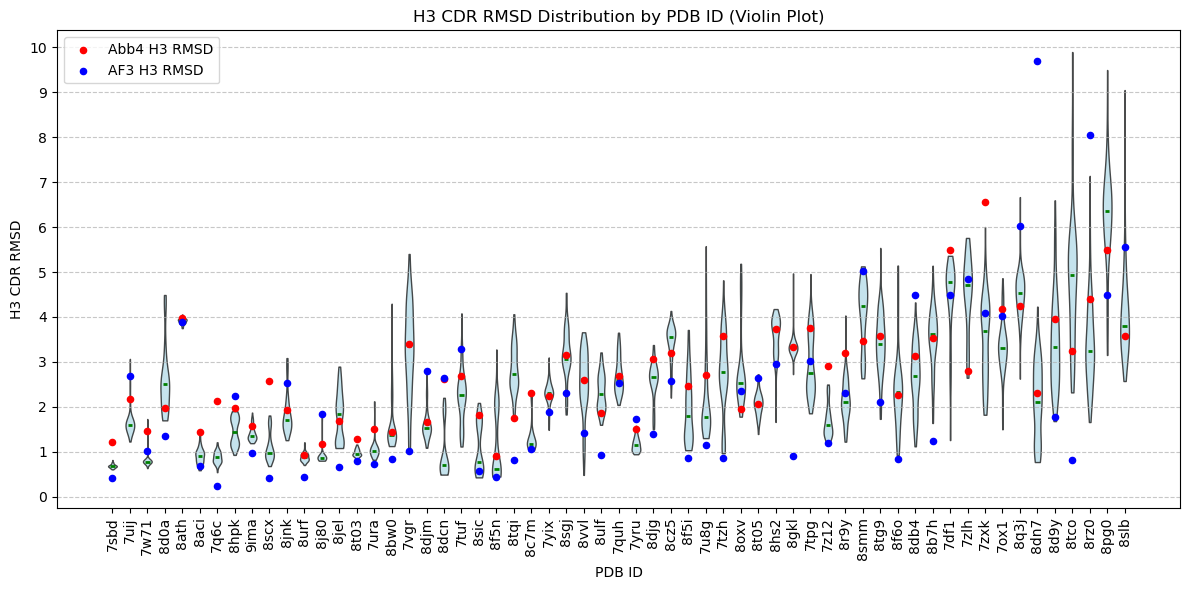

In [5]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
prev_project_dir = '/home/psh/project_v2/final_output/abb_v4.4_general_x1/first_stage/only_cdr'
af3_dir = '/home/psh/project_v2/final_output/af3/only_cdr'
csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

pdb_ids = []  # 🔹 여기에 PDB ID 추가할 것

for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 이전 프로젝트에서 RMSD 값 불러오기
    prev_filepath = os.path.join(prev_project_dir, pdb_id + '.json')
    if os.path.exists(prev_filepath):
        with open(prev_filepath, 'r') as f:
            prev_data = json.load(f)
        h3_rmsd_by_pdb_prev[pdb_key] = prev_data['h3_rms']
    else:
        h3_rmsd_by_pdb_prev[pdb_key] = 5.5  # 기본값 설정

    # af3에서 RMSD 값 불러오기 
    af3_filepath = os.path.join(af3_dir, pdb_id + '.json')
    if os.path.exists(af3_filepath):
        with open(af3_filepath, 'r') as f:
            af3_data = json.load(f)
        h3_rmsd_by_pdb_af3[pdb_key] = af3_data['h3_rms']
    else:
        h3_rmsd_by_pdb_af3[pdb_key] = 4.5  # 기본값 설정

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
pdb_names_sorted = df_sorted["pdb_name"].tolist()
pdb_names_sorted = [filename.split('_')[0] for filename in pdb_names_sorted]
# 📌 정렬된 순서로 RMSD 값을 가져오기
h3_rmsd_sorted = [h3_rmsd_by_pdb.get(pdb, []) for pdb in pdb_names_sorted]  # 데이터 없는 경우 빈 리스트 처리
prev_values_sorted = [h3_rmsd_by_pdb_prev.get(pdb, None) for pdb in pdb_names_sorted]
af3_values_sorted = [h3_rmsd_by_pdb_af3.get(pdb, None) for pdb in pdb_names_sorted]

# 📌 Violin plot 그리기
plt.figure(figsize=(12, 6))
parts = plt.violinplot(h3_rmsd_sorted, showmeans=False, showmedians=True, showextrema=False)

# Violin plot 스타일 설정
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 중앙값 표시 (violin plot에서 이미 showmedians=True로 설정했지만 추가로 커스터마이징)
parts['cmedians'].set_color('green')
parts['cmedians'].set_linewidth(2)

# 🔹 이전 프로젝트 및 AF3 RMSD 값 표시
x_positions = np.arange(1, len(pdb_names_sorted) + 1)
plt.scatter(x_positions, prev_values_sorted, color='red', marker='o', s=20, label="Abb4 H3 RMSD", zorder=3)
plt.scatter(x_positions, af3_values_sorted, color='blue', marker='o', s=20, label="AF3 H3 RMSD", zorder=3)

# 그래프 설정
plt.xlabel("PDB ID")
plt.ylabel("H3 CDR RMSD")
plt.xticks(x_positions, pdb_names_sorted, rotation=90)  # PDB ID가 많을 경우 가독성을 위해 회전
plt.title("H3 CDR RMSD Distribution by PDB ID (Violin Plot)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.yticks([i for i in range(11)])

# 여백 조정
plt.tight_layout()

# 그래프 표시
plt.show()

## 각 pdb에서 상위 10위 추출

In [5]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/run_2025-10-15_16-05-43'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 20

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

1.3356652889651275


### 각 모델 별 rmsd 비교 

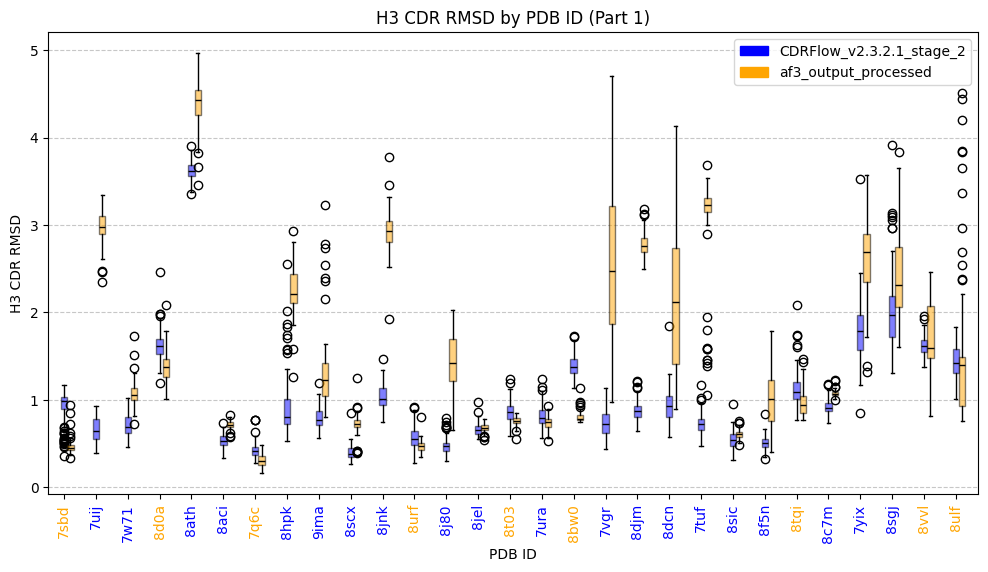

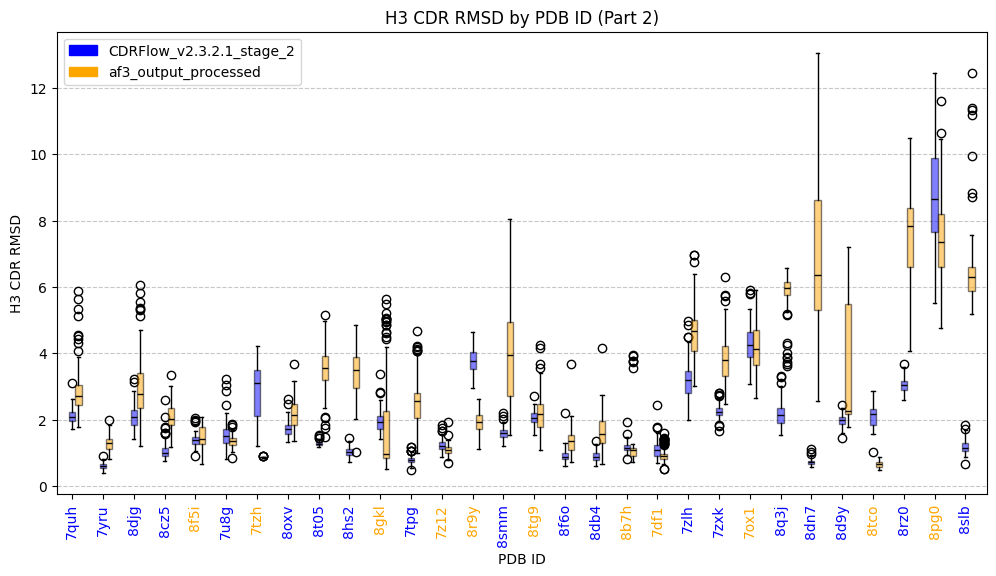

In [ ]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            if 'sample' not in sample:
                continue
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 2
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir.split('/')[5] if len(dir.split('/')) > 5 else dir.split('/')[3]
    )
    for idx, dir in enumerate(pred_dirs)
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]

        # 박스플롯 그리기
        boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2,
                              patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                              medianprops=dict(color='black'))

        # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
        for rmsd_list in h3_rmsd_sorted:
            sorted_rmsd = sorted(rmsd_list)
            if len(sorted_rmsd) >= 10:
                tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
            else:
                tenth_value = None  # 또는 np.nan
            tenth_values[pred_dir].append(tenth_value)

    # 중앙값 비교 후 색상 결정
    xlabel_colors = []
    for j, pdb in enumerate(pdb_subset):
        if tenth_values[pred_dirs[0]][j] < tenth_values[pred_dirs[1]][j]:
            xlabel_colors.append(colors[0])  # 첫 번째 모델 색상
        else:
            xlabel_colors.append(colors[1])  # 두 번째 모델 색상

    # 📌 PDB ID의 색상 
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)  # color 제거

    # 📌 x축 레이블 개별적으로 색상 설정
    ax = plt.gca()  # 현재 축 가져오기
    for label, color in zip(ax.get_xticklabels(), xlabel_colors):
        label.set_color(color)


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)

    # 그래프 표시
    plt.show()



# check self-confidence correlation 

100
100
{'/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_33/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_56/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_84/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_87/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C/sample_47/sample_1.pdb', '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-4

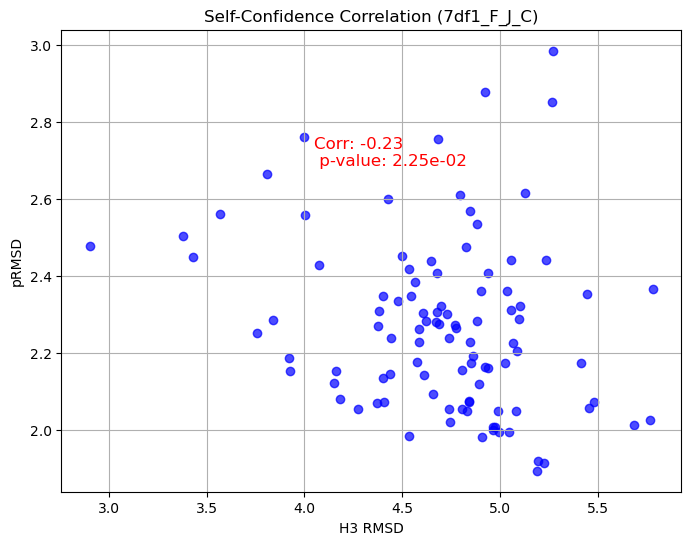

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

def calculate_b_factor_mean(pdb_dir, start_residue=95, end_residue=102):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in sorted(os.listdir(pdb_dir)):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())
                
        b_factors_avg.append(np.mean(b_factors))
            
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_tri_aa_nb_sample_x2_crop300_rollout/2025-05-07_15-51-01/last/run_2025-05-07_21-41-03/7df1_F_J_C'
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir)

# RMSD 값 수집

cdr_rmsd_dir = pdb_dir
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(cdr_rmsd_dir)):

    json_file = os.path.join(cdr_rmsd_dir, sample, 'cdr_rmsd.json')
    json_paths.append(json_file)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    h3_rmsd = rmsd_data.get('h3_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if h3_rmsd is not None:
        rmsd_values.append(h3_rmsd)

print(len(rmsd_values))
print(len(b_factors))

print(set(pdb_paths) - set(json_paths))
correlation_coefficient = spearmanr(rmsd_values, b_factors)
print(correlation_coefficient)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.7)
plt.text(max(rmsd_values) * 0.7, max(b_factors) * 0.9, f"Corr: {correlation_coefficient[0]:.2f} \n p-value: {correlation_coefficient[1]:.2e}", fontsize=12, color='red')

# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation (7df1_F_J_C)")
plt.xlabel("H3 RMSD")
plt.ylabel("pRMSD")
plt.grid(True)
plt.show()



In [14]:
import torch 

data = torch.load('/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/last.ckpt', map_location='cpu')


In [15]:
print(data['callbacks'])

{"ModelCheckpoint{'monitor': 'valid/h3_trans_loss', 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None}": {'monitor': 'valid/h3_trans_loss', 'best_model_score': tensor(1.3872), 'best_model_path': '/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/epoch=96-step=139001.ckpt', 'current_score': tensor(1.3872), 'dirpath': '/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40', 'best_k_models': {'/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/epoch=72-step=104609.ckpt': tensor(1.4371), '/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/epoch=93-step=134702.ckpt': tensor(1.4244), '/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/epoch=96-step=139001.ckpt': tensor(1.3872)}, 'kth_best_model_path': '/home/psh/protein-frame-flow/ckpt/v2.0.0/CDRFlow_v2.3.1.1/2025-09-10_17-24-40/epoch=72-step=104609.ckpt', 'kth_value': te

['sample_0', 'sample_1', 'sample_10', 'sample_11', 'sample_12', 'sample_13', 'sample_14', 'sample_15', 'sample_16', 'sample_17', 'sample_18', 'sample_19', 'sample_2', 'sample_20', 'sample_21', 'sample_22', 'sample_23', 'sample_24', 'sample_25', 'sample_26', 'sample_27', 'sample_28', 'sample_29', 'sample_3', 'sample_30', 'sample_31', 'sample_32', 'sample_33', 'sample_34', 'sample_35', 'sample_36', 'sample_37', 'sample_38', 'sample_39', 'sample_4', 'sample_40', 'sample_41', 'sample_42', 'sample_43', 'sample_44', 'sample_45', 'sample_46', 'sample_47', 'sample_48', 'sample_49', 'sample_5', 'sample_50', 'sample_51', 'sample_52', 'sample_53', 'sample_54', 'sample_55', 'sample_56', 'sample_57', 'sample_58', 'sample_59', 'sample_6', 'sample_60', 'sample_61', 'sample_62', 'sample_63', 'sample_64', 'sample_65', 'sample_66', 'sample_67', 'sample_68', 'sample_69', 'sample_7', 'sample_70', 'sample_71', 'sample_72', 'sample_73', 'sample_74', 'sample_75', 'sample_76', 'sample_77', 'sample_78', 'sampl

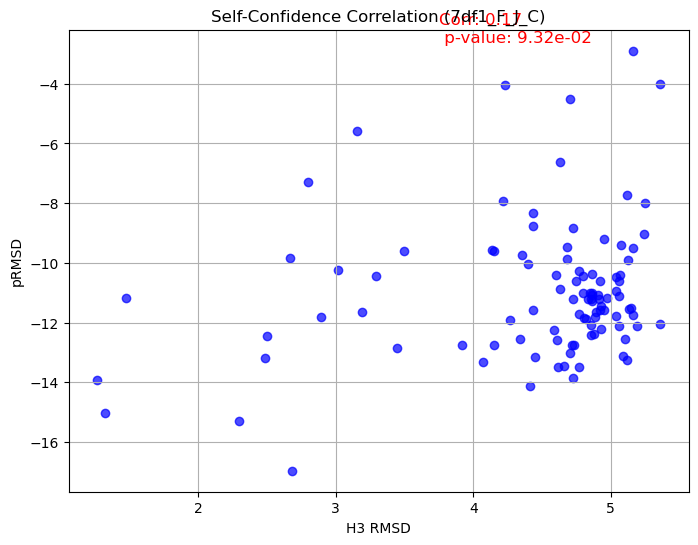

In [10]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

# PDB 디렉터리 설정
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37/7df1_F_J_C'
energy_dir = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/interface_energy/7df1_F_J_C'

energy = []
energy_files = []
for file in sorted(os.listdir(energy_dir)):
    energy_files.append(file.replace('.json', ''))
    with open(os.path.join(energy_dir, file)) as f:
        data = json.load(f)
        energy.append(data['h3_cdr_total_energies']['fa_elec'])
# RMSD 값 수집
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(pdb_dir)):

    json_file = os.path.join(pdb_dir, sample, 'cdr_rmsd.json')
    json_paths.append(sample)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    h3_rmsd = rmsd_data.get('h3_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if h3_rmsd is not None:
        rmsd_values.append(h3_rmsd)

print(energy_files)
print(json_paths)

correlation_coefficient = spearmanr(rmsd_values, energy)
print(correlation_coefficient)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, energy, color='blue', alpha=0.7)
plt.text(max(rmsd_values) * 0.7, max(energy) * 0.9, f"Corr: {correlation_coefficient[0]:.2f} \n p-value: {correlation_coefficient[1]:.2e}", fontsize=12, color='red')

# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation (7df1_F_J_C)")
plt.xlabel("H3 RMSD")
plt.ylabel("pRMSD")
plt.grid(True)
plt.show()



## Loss와 실제 H3 rmsd 상관관계 

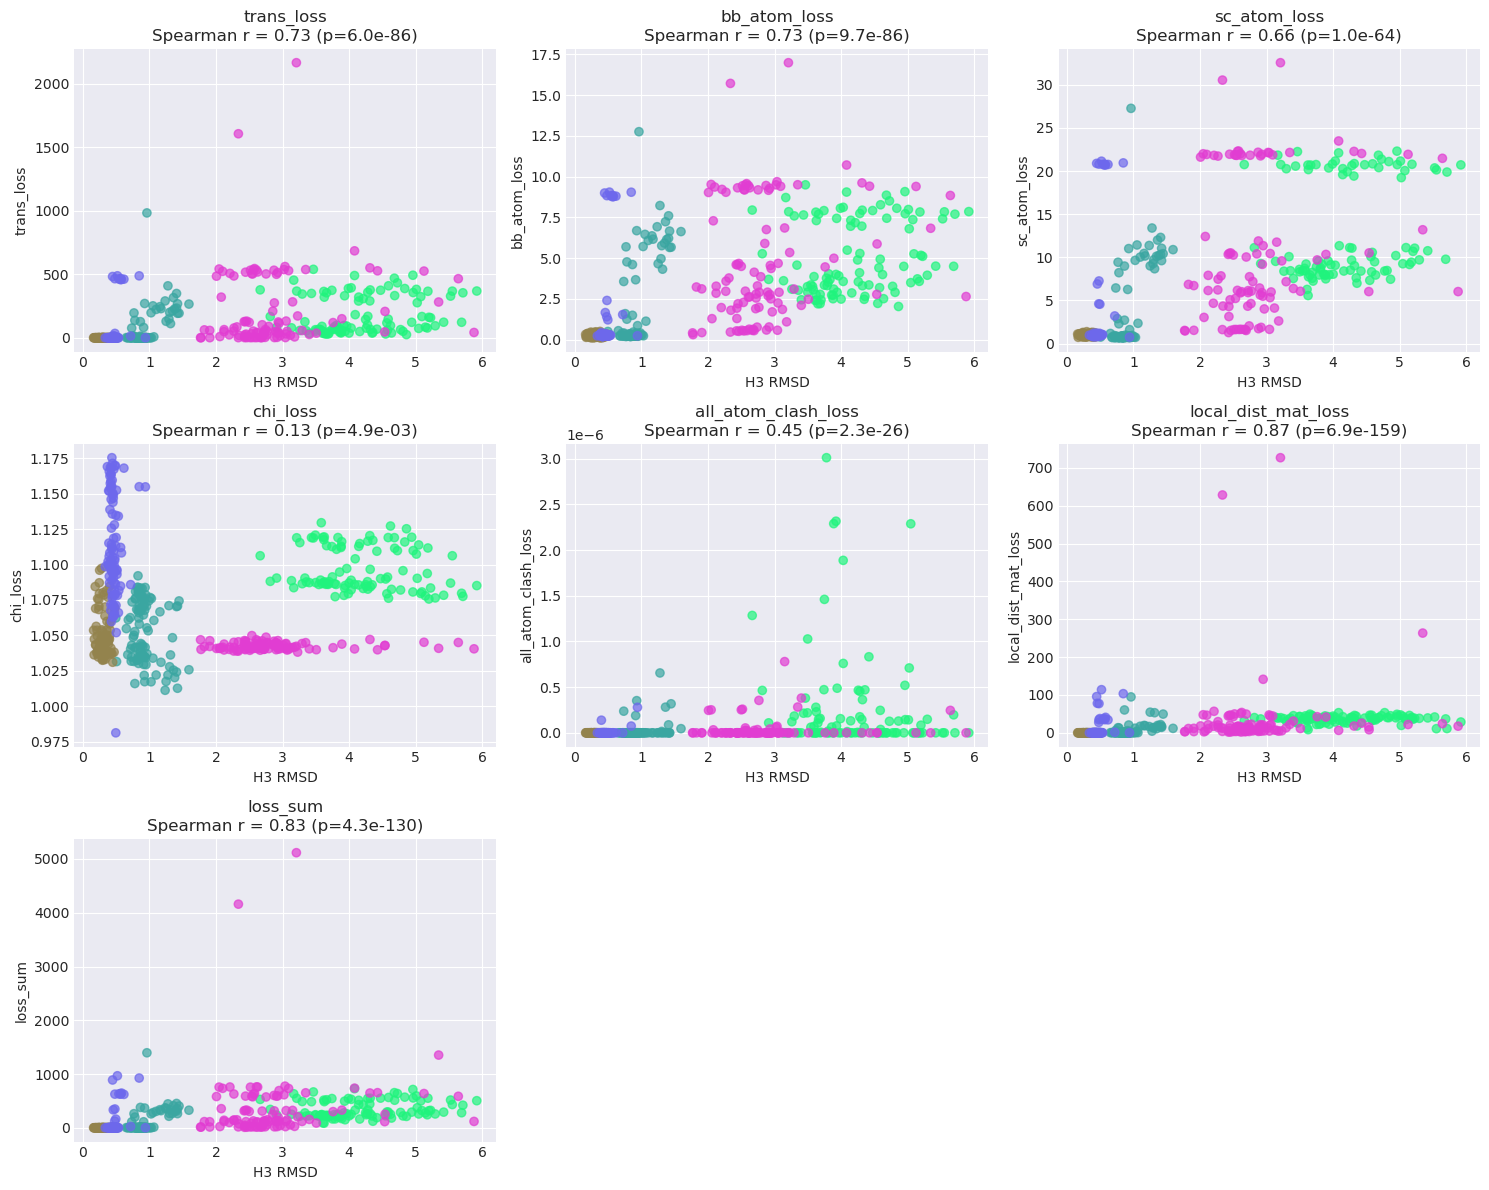

In [ ]:
import os 
import json 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

pred_dir = '/home/psh/protein-frame-flow/pred_samples'
sample_num = 100
show_num = 5

h3_cdr = []
total_loss = {
    "trans_loss": [], "bb_atom_loss": [], "sc_atom_loss": [], "chi_loss": [],
    "all_atom_clash_loss": [], "local_dist_mat_loss": [], "se3_vf_loss": []
}

# 각 pdb_name에 대해 색깔을 할당할 딕셔너리
pdb_colors = {}

# 데이터 수집
for j, pdb_name in enumerate(os.listdir(pred_dir)):
    pdb_dir = os.path.join(pred_dir, pdb_name)
    
    if pdb_name not in pdb_colors:
        pdb_colors[pdb_name] = np.random.rand(3,)  # RGB 색상 생성
    
    for i in range(sample_num):
        loss_file = os.path.join(pdb_dir, f'af3_sample_{i}_loss.json')
        cdr_file = os.path.join(pdb_dir, f'af3_sample_{i}.json')

        with open(loss_file) as f:
            loss_data = json.load(f)
            for loss_type, loss in loss_data.items():
                total_loss[loss_type].append(loss)
            
        with open(cdr_file) as f:
            cdr_data = json.load(f)
            h3_cdr.append(cdr_data['h3_rms'])

    if j == show_num - 1:
        break

# se3_vf_loss -> loss_sum으로 변경
total_loss["loss_sum"] = total_loss.pop("se3_vf_loss")

# 그래프 스타일
plt.style.use('seaborn-v0_8-darkgrid')

num_losses = len(total_loss)
cols = 3
rows = (num_losses + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# 색상 리스트 생성 (전체 샘플에 대해)
pdb_list = os.listdir(pred_dir)[:show_num]
colors = [pdb_colors[pdb_name] for pdb_name in pdb_list for _ in range(sample_num)]

# 각 loss에 대해 그래프 및 스피어만 상관계수 출력
for i, (loss_type, loss_values) in enumerate(total_loss.items()):
    ax = axes[i]
    
    # Spearman correlation 계산
    rho, pval = spearmanr(h3_cdr, loss_values)
    title = f"{loss_type}\nSpearman r = {rho:.2f} (p={pval:.1e})"
    
    ax.scatter(h3_cdr, loss_values, c=colors, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("H3 RMSD")
    ax.set_ylabel(loss_type)

# 남는 subplot 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# CDF 형태의 plot

config.yaml
7df1_F_J_C
7ox1_A_B_G
7q6c_H_L_A
7quh_H_L_A
7sbd_H_L_C
7tpg_H_L_B
7tuf_A_B_C
7tzh_C_Z_D
7u8g_D_E_A
7uij_H_L_CD
7ura_H_L_A
7vgr_D_C_AB
7w71_I_M_B
7yix_D_Z_AB
7yru_H_L_A
7z12_B_C_A
7zlh_H_L_A
7zxk_J_I_AB
8aci_H_L_A
8ath_E_F_B
8b7h_H_L_AB
8bw0_H_L_C
8c7m_C_D_B
8cz5_H_L_A
8d0a_H_L_A
8d9y_B_A_I
8db4_A_B_E
8dcn_D_E_F
8djg_C_D_E
8djm_H_L_BA
8dn7_D_H_E
8f5i_X_Y_A
8f5n_H_L_A
8f6o_A_B_C
8gkl_H_L_E
8hpk_H_L_A
8hs2_B_C_R
8j80_E_C_AB
8jel_C_D_J
8jnk_I_M_A
8oxv_B_C_A
8pg0_H_L_A
8q3j_C_B_A
8r9y_B_C_A
8rz0_F_Z_E
8scx_H_L_ABC
8sgj_H_L_A
8sic_A_B_E
8slb_H_L_A
8smm_H_L_A
8t03_C_D_AB
8t05_C_D_AB
8tco_F_G_ABC
8tg9_E_F_B
8tqi_H_L_AB
8ulf_H_L_AB
8urf_H_L_A
8vvl_H_L_A
9ima_C_D_AB


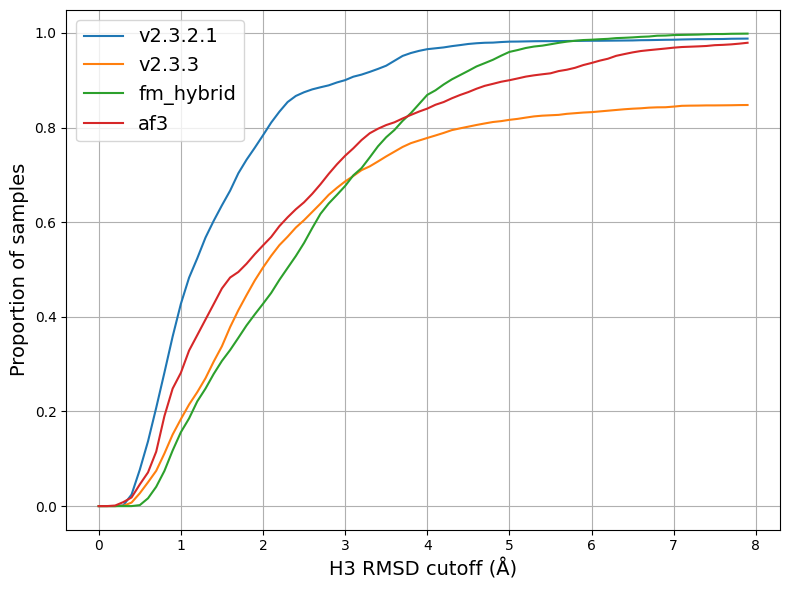

In [2]:
pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/run_2025-10-15_16-05-43'
af3_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.3_stage_2/2025-10-14_00-45-15/epoch=23-step=34392/run_2025-10-15_10-59-20'
pred_dir_wo_atom = '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37'
pred_new_dir = '/home/psh/af3_output_processed/'
import os 
import json 

pred_cdrs = []
pred_wo_atom = []
af3_cdrs = []
pred_new_cdrs = []
for pdb in os.listdir(pred_dir):
    print(pdb)
    if 'config' in pdb:
        continue
    af3_pdb = os.path.join(af3_dir, pdb)
    pred_pdb = os.path.join(pred_dir, pdb)
    pred_wo_atom_pdb = os.path.join(pred_dir_wo_atom, pdb)
    pred_new_pdb = os.path.join(pred_new_dir, pdb)
    for sample in os.listdir(pred_pdb):
        if 'sample' not in sample:
            continue
        pred_cdr_json = os.path.join(pred_pdb, sample, "cdr_rmsd.json")
        af3_cdr_json = os.path.join(af3_pdb, sample, "cdr_rmsd.json")
        pred_wo_atom_json = os.path.join(pred_wo_atom_pdb, sample, "cdr_rmsd.json")
        pred_new_json = os.path.join(pred_new_pdb, sample, "cdr_rmsd.json")

        with open(pred_cdr_json, 'r') as f:
            pred_cdr_data = json.load(f)
        pred_cdrs.append(pred_cdr_data['h3_rms'])

        with open(af3_cdr_json, 'r') as f:
            af3_cdr_data = json.load(f)
        af3_cdrs.append(af3_cdr_data['h3_rms'])

        with open(pred_wo_atom_json, 'r') as f:
            pred_wo_atom_cdr_data = json.load(f)
        pred_wo_atom.append(pred_wo_atom_cdr_data['h3_rms'])

        with open(pred_new_json, 'r') as f:
            pred_new_cdr_data = json.load(f)
        pred_new_cdrs.append(pred_new_cdr_data['h3_rms'])
import matplotlib.pyplot as plt
import numpy as np

# numpy array로 변환
pred_cdrs = np.array(pred_cdrs)
af3_cdrs = np.array(af3_cdrs)
pred_wo_atom_cdrs = np.array(pred_wo_atom)
pred_new_cdrs = np.array(pred_new_cdrs) 

# cutoff 범위 설정 (0부터 5까지 0.1 간격)
cutoffs = np.arange(0, 8, 0.1)

# 각 cutoff 이하인 비율 계산
pred_cdf = [(pred_cdrs <= c).sum() / len(pred_cdrs) for c in cutoffs]
af3_cdf = [(af3_cdrs <= c).sum() / len(af3_cdrs) for c in cutoffs]
pred_wo_atom_cdf = [(pred_wo_atom_cdrs <= c).sum() / len(pred_wo_atom_cdrs) for c in cutoffs]
pred_new_cdrs_cdf = [(pred_new_cdrs <= c).sum() / len(pred_new_cdrs) for c in cutoffs]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(cutoffs, pred_cdf, label='v2.3.2.1')
plt.plot(cutoffs, af3_cdf, label='v2.3.3')
plt.plot(cutoffs, pred_wo_atom_cdf, label='fm_hybrid')
plt.plot(cutoffs, pred_new_cdrs_cdf, label='af3')
# plt.plot(cutoffs, pred_wo_ag, label='CDRFlow w/o Ag')
plt.xlabel('H3 RMSD cutoff (Å)', fontsize=14)
plt.ylabel('Proportion of samples', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


# scatter plot (AF3 vs CDRFlow) by DockQ score 

In [9]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/fm_hybrid/2025-05-28_17-17-52/epoch=105-step=150096_copy/run_2025-05-31_09-40-37',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
dockq_by_pdb_indexed = {}
all_pdb_ids = set()

energy_dir = '/home/psh/benchmark_after210930/interface_energy'
h3_sasa = {}

for file in os.listdir(energy_dir):
    # collect h3 average delta sasa 
    energy_json = os.path.join(energy_dir, file)
    with open(energy_json, 'r') as f:
        energy_data = json.load(f)

    pdb_id = file.replace('.json', '').split('_')[0]
    h3_sasa[pdb_id] = energy_data['h3_sasa_avg']

# RMSD 및 DockQ 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        dockqs = []

        sample_dirs = sorted(os.listdir(sub_dir))
        for sample in sample_dirs:
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])


        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

# Plot 준비
# Plot 준비
x_vals = []
y_vals = []
sasa_vals = []
valid_pdb_ids = []


for pdb in list(all_pdb_ids):
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    # 27번째 AF3 RMSD 기준
    sorted_rmsd2_with_index = sorted(enumerate(rmsd_list_2), key=lambda x: x[1])
    idx_27th = sorted_rmsd2_with_index[26][0]
    rmsd_27th = sorted_rmsd2_with_index[26][1]
    if '8dcn' in pdb:
        rmsd_27th = 2.5

    rmsd_16th = sorted(rmsd_list_1)[15]

    sasa = h3_sasa[pdb]
    x_vals.append(rmsd_27th)
    y_vals.append(rmsd_16th)
    sasa_vals.append(sasa)
    valid_pdb_ids.append(pdb)

# 분위수 계산
quantiles = pd.qcut(sasa_vals, q=4, labels=False, duplicates='drop')
quantile_bins = pd.qcut(sasa_vals, q=4, duplicates='drop')
quantile_ranges = quantile_bins.unique().sort_values()

# colormap 색상
cmap = cm.get_cmap('viridis', 4)
custom_cmap = [
    '#d62728', 
    '#ff7f0e',  
    '#2ca02c', 
    '#1f77b4',  
]

colors = [custom_cmap[q] for q in quantiles]
# 조건에 맞는 인덱스 추출
q1_below = [i for i in range(len(x_vals)) if y_vals[i] < x_vals[i] and quantiles[i] == 0]
q4_above = [i for i in range(len(x_vals)) if y_vals[i] > x_vals[i] and quantiles[i] == 3]

# 임의 선택 (서로 바꿀 짝수 개수)
np.random.seed(42)
n = min(5, len(q1_below), len(q4_above))  # 예: 최대 5개
q1_sample = np.random.choice(q1_below, size=n, replace=False)
q4_sample = np.random.choice(q4_above, size=n, replace=False)

# 색상 복사해서 수정
modified_colors = colors.copy()
for i, j in zip(q1_sample, q4_sample):
    # 색상을 서로 바꿈
    modified_colors[i], modified_colors[j] = modified_colors[j], modified_colors[i]

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=modified_colors, edgecolor='k', alpha=0.8, s=60)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

# 범례
legend_elements = [
    Patch(facecolor=custom_cmap[i], edgecolor='k',
          label=f'{q.left:.3f} ~ {q.right:.3f}')
    for i, q in enumerate(quantile_ranges)
]
plt.legend(handles=legend_elements, title="H3 |ΔSASA| Quartile (Å²)", fontsize=13, title_fontsize=14)

plt.xlabel('AF3 H3 RMSD (Å)', fontsize=16)
plt.ylabel('CDRFlow H3 RMSD (Å)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 